# **Regression: Random Forest Regressor (RFR)**

## **Justification of Preprocessing Strategy**

### **Scale Invariance**
The Random Forest Regressor is an ensemble method built entirely upon Decision Trees. Because individual trees partition data based on discrete threshold rules (e.g., `BMI > 30`) rather than calculating geometric distances, the entire ensemble inherits this mathematical scale-invariance. Standardization or Normalization will not alter the model's splitting logic or improve predictive performance. To preserve clinical interpretability and maximize computational efficiency, we will train the model using the **Original, Unscaled Data**.

### **Architectural Knowledge Transfer (Structural Regularization)**
By default, Scikit-Learn's Random Forest allows base trees to grow unconstrained (`max_depth=None`), which inevitably leads to severe memorization (Overfitting) on a 100,000-row dataset. Instead of starting blind, we will apply **Architectural Knowledge Transfer**. We extract the structural boundaries discovered in our standalone Decision Tree Regressor champion (`max_depth=20`, `min_samples_leaf=10`, `min_samples_split=10`) and inject them as the foundational blueprint for every tree in our forest. This guarantees a mathematically safe baseline.

## **Experiment Design**

We designed a tournament of 3 optimization levels. We strictly log **both Train and Test metrics (RMSE, MAE, R²)** to explicitly monitor the Overfitting Gap:

* **Architectural Baseline**: 100 trees built using the exact structural parameters of our Decision Tree champion, establishing a robust, pre-regularized performance floor.
* **GridSearchCV**: A highly targeted 3-fold cross-validated search exploring around our champion's boundaries. We focus primarily on ensemble-specific mechanisms such as `max_features` (to decorrelate the trees) and ensemble size (`n_estimators`).
* **Optuna Optimization**: Bayesian optimization utilizing a safe trial budget to explore the continuous parameter space around our champion's depth and leaf constraints, while introducing data starvation (`max_samples`) to maximize ensemble diversity and minimize the validation RMSE.

[I 2026-05-23 14:59:58,385] A new study created in memory with name: no-name-5c8c27b7-4c6f-4255-a823-58cadc5fe75f
[I 2026-05-23 15:00:27,583] Trial 0 finished with value: 1.1242025676851426 and parameters: {'n_estimators': 160, 'max_depth': 23, 'min_samples_leaf': 14, 'min_samples_split': 17, 'max_features': 1.0, 'max_samples': 0.6031935779214013}. Best is trial 0 with value: 1.1242025676851426.
[I 2026-05-23 15:00:30,948] Trial 1 finished with value: 2.59200403421033 and parameters: {'n_estimators': 136, 'max_depth': 14, 'min_samples_leaf': 20, 'min_samples_split': 16, 'max_features': 'log2', 'max_samples': 0.6210310123603342}. Best is trial 0 with value: 1.1242025676851426.
[I 2026-05-23 15:00:35,129] Trial 2 finished with value: 2.567957972986865 and parameters: {'n_estimators': 159, 'max_depth': 15, 'min_samples_leaf': 20, 'min_samples_split': 17, 'max_features': 'log2', 'max_samples': 0.7117296555479428}. Best is trial 0 with value: 1.1242025676851426.
[I 2026-05-23 15:00:38,604] 

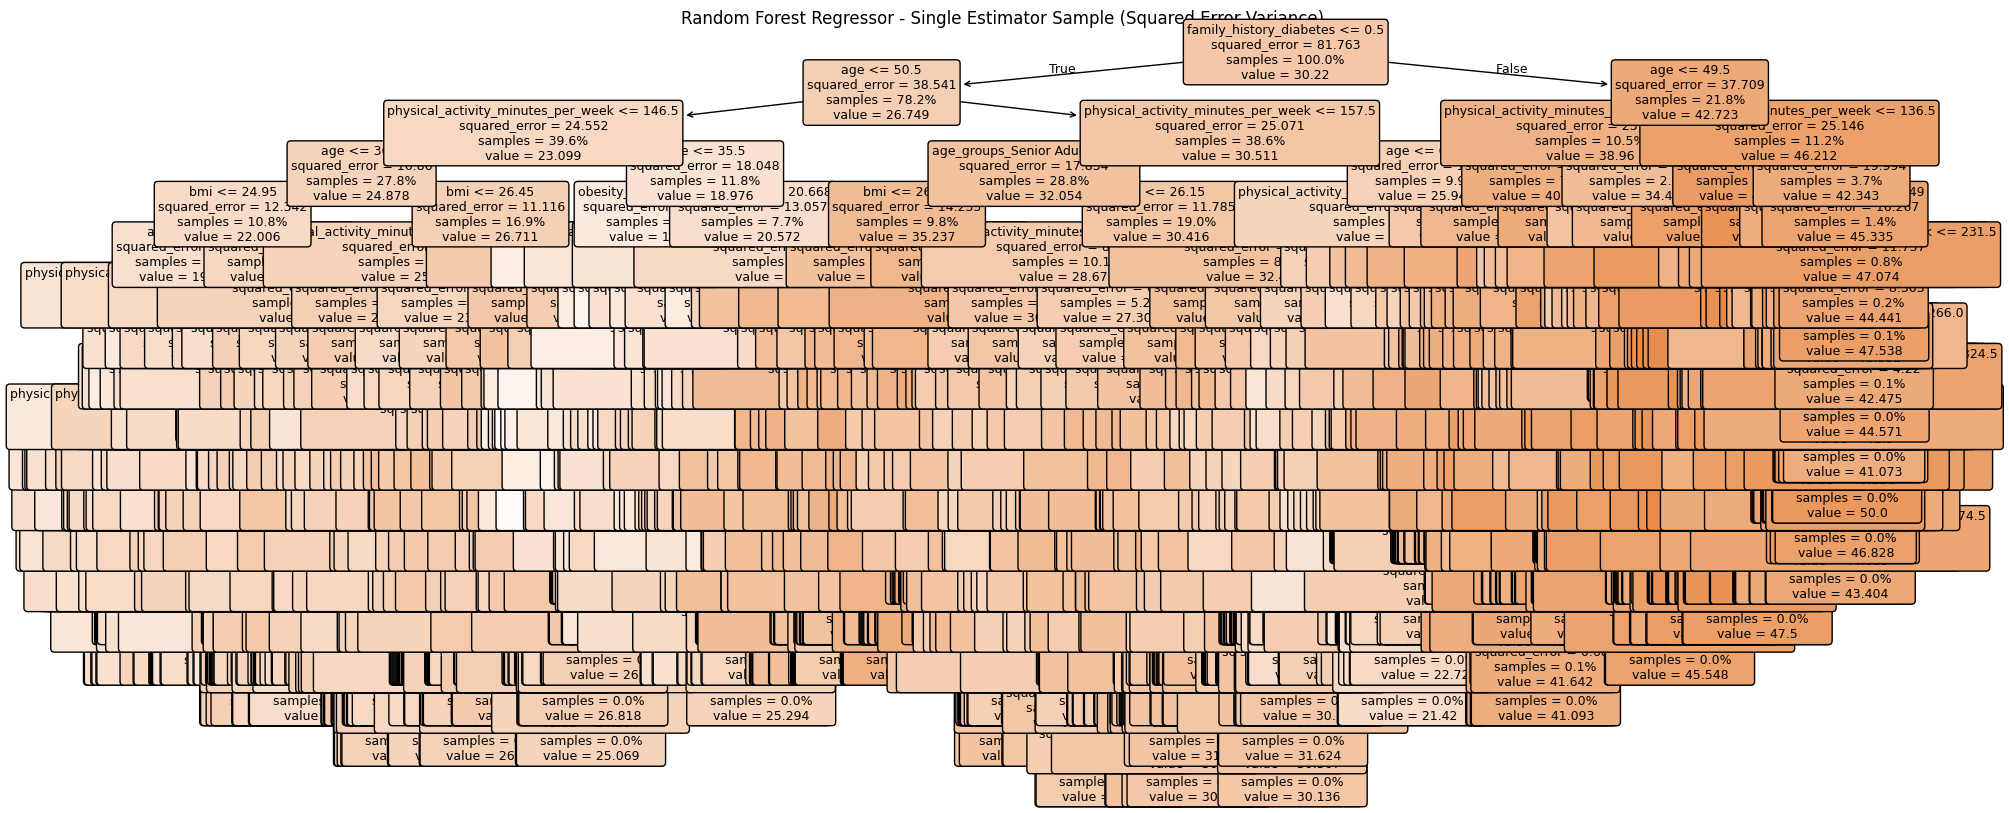

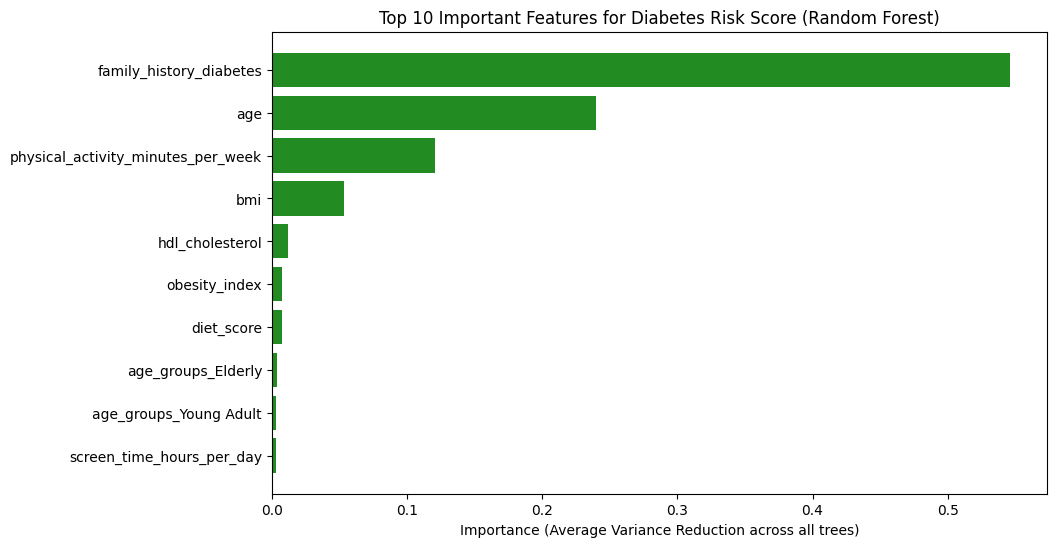

In [ ]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import plot_tree

# MLflow Configuration
mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Regression_RandomForest")

# Data Loading and Preparation
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")

categorical_cols = [
    'gender', 'ethnicity', 'smoking_status', 'education_level',
    'employment_status', 'age_groups', 'weight_status', 'income_level'
]

# Apply One-Hot Encoding
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target 
# Drop classification targets to prevent data leakage!
X = df_final.drop(["diagnosed_diabetes", "diabetes_stage", "diabetes_risk_score"], axis=1)
y = df_final['diabetes_risk_score']

# Split data (80/20) - No stratify needed for continuous targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SEED = 42

def log_regression_metrics(y_tr_true, y_tr_pred, y_te_true, y_te_pred, duration):
    # Logs Train and Test metrics explicitly to monitor the Overfitting Gap
    # Train Partition Metrics
    mlflow.log_metric("rmse_train", mean_squared_error(y_tr_true, y_tr_pred) ** 0.5)
    mlflow.log_metric("mae_train", mean_absolute_error(y_tr_true, y_tr_pred))
    mlflow.log_metric("r2_train", r2_score(y_tr_true, y_tr_pred))
    
    # Test Partition Metrics
    mlflow.log_metric("rmse_test", mean_squared_error(y_te_true, y_te_pred) ** 0.5)
    mlflow.log_metric("mae_test", mean_absolute_error(y_te_true, y_te_pred))
    mlflow.log_metric("r2_test", r2_score(y_te_true, y_te_pred))
    
    mlflow.log_metric("fit_time", duration)

# ---------------------------------------------------------
# RUN 1: BASELINE 
# ---------------------------------------------------------
with mlflow.start_run(run_name="RFR_Baseline_Architectural"):
    # Injecting the Decision Tree Champion parameters
    reg_base = RandomForestRegressor(
        n_estimators=100,
        criterion="squared_error",
        max_depth=20,
        min_samples_leaf=10,
        min_samples_split=10,
        random_state=SEED, 
        n_jobs=-1
    )
    
    start_time = time.time()
    reg_base.fit(X_train, y_train)
    duration = time.time() - start_time
    
    # Explicit Predictions
    y_pred_train_base = reg_base.predict(X_train)
    y_pred_test_base = reg_base.predict(X_test)
    
    mlflow.log_params(reg_base.get_params())
    mlflow.log_param("optimization", "none_architectural_transfer")
    
    log_regression_metrics(y_train, y_pred_train_base, y_test, y_pred_test_base, duration)

# ---------------------------------------------------------
# RUN 2: GRIDSEARCHCV 
# ---------------------------------------------------------
with mlflow.start_run(run_name="RFR_GridSearch"):
    # Searching closely around our known champion boundaries
    param_grid = {
        "n_estimators": [100, 150],
        "max_depth": [15, 20, 25],
        "min_samples_leaf": [10, 20],
        "max_features": ["sqrt", 1.0] # 1.0 is default, sqrt decorrelates trees
    }

    grid_reg = GridSearchCV(
        estimator=RandomForestRegressor(criterion="squared_error", random_state=SEED, n_jobs=-1),
        param_grid=param_grid,
        cv=KFold(n_splits=3, shuffle=True, random_state=SEED), # 3-fold for speed
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    start_time = time.time()
    grid_reg.fit(X_train, y_train)
    duration = time.time() - start_time

    best_rfr_grid = grid_reg.best_estimator_
    
    # Explicit Predictions
    y_pred_train_grid = best_rfr_grid.predict(X_train)
    y_pred_test_grid = best_rfr_grid.predict(X_test)

    mlflow.log_params(grid_reg.best_params_)
    mlflow.log_param("optimization", "GridSearchCV")
    
    log_regression_metrics(y_train, y_pred_train_grid, y_test, y_pred_test_grid, duration)

# ---------------------------------------------------------
# RUN 3: OPTUNA 
# ---------------------------------------------------------
def objective_reg(trial):
    # Dynamic search space anchored around the DT Champion
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 10, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "max_samples": trial.suggest_float("max_samples", 0.6, 0.9) # Data starvation
    }

    model = RandomForestRegressor(**params, criterion="squared_error", random_state=SEED, n_jobs=-1)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()

with mlflow.start_run(run_name="RFR_Optuna"):
    study_reg = optuna.create_study(direction="minimize")
    
    start_time = time.time()
    study_reg.optimize(objective_reg, n_trials=12) 
    duration = time.time() - start_time

    best_rfr_optuna = RandomForestRegressor(**study_reg.best_params, criterion="squared_error", random_state=SEED, n_jobs=-1)
    best_rfr_optuna.fit(X_train, y_train)
    
    # Explicit Predictions
    y_pred_train_optuna = best_rfr_optuna.predict(X_train)
    y_pred_test_optuna = best_rfr_optuna.predict(X_test)

    mlflow.log_params(study_reg.best_params)
    mlflow.log_param("optimization", "optuna")
    
    log_regression_metrics(y_train, y_pred_train_optuna, y_test, y_pred_test_optuna, duration)

# ---------------------------------------------------------
# VISUALIZATION: Plotting ONE Tree from the Forest 
# ---------------------------------------------------------
plt.figure(figsize=(22, 10))
# Extracting the very first tree (estimator index 0) from our Optuna champion forest
single_tree_reg = best_rfr_optuna.estimators_[0]

plot_tree(
    single_tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    proportion=True
)
plt.title("Random Forest Regressor - Single Estimator Sample (Squared Error Variance)")
plt.show()

# ---------------------------------------------------------
# VISUALIZATION: Feature Importance for the entire Forest
# ---------------------------------------------------------
importance_df_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rfr_optuna.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_reg["Feature"], importance_df_reg["Importance"], color='forestgreen')
plt.xlabel("Importance (Average Variance Reduction across all trees)")
plt.title("Top 10 Important Features for Diabetes Risk Score (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


## Winner Run Selection

### Policy
A run is only eligible to win if it does NOT show evidence of overfitting or underfitting. Before applying the MAE/RMSE/R² decision rules, we require the Train→Test gaps to remain small enough to indicate acceptable generalization. Runs that memorize the training set or show a large Train/Test gap are disqualified regardless of metric rank.

### Selection Criteria (priority order)
1. **Generalization filter (mandatory):** runs with overfitting or underfitting are removed from consideration.
2. **Priority 1 (60%): Lowest MAE (Test)** — primary objective for regression accuracy.
3. **Priority 2 (30%): Lowest RMSE (Test)** — used to reject runs where RMSE grows disproportionately relative to MAE.
4. **Priority 3 (10%): Acceptable R² (Test)** — confirms explanatory quality.
5. **Tiebreaker: Lowest Fit Time** — if MAE, RMSE, and R² are effectively tied.

### Runs Summary

| Run | MAE (Train) | MAE (Test) | RMSE (Train) | RMSE (Test) | R² (Train) | R² (Test) | Fit Time |
|---|---:|---:|---:|---:|---:|---:|---:|
| RFR_Baseline_Architectural | 0.52251 | 0.72780 | 0.70219 | 0.95514 | 0.99399 | 0.98895 | 14.38s |
| RFR_GridSearch | 0.51939 | 0.72491 | 0.69852 | 0.95160 | 0.99405 | 0.98903 | 473.33s |
| RFR_Optuna | 0.63119 | 0.78279 | 0.84013 | 1.02401 | 0.99139 | 0.98729 | 137.60s |

### Generalization Check (Test − Train)
- **RFR_Baseline_Architectural:** MAE gap = 0.72780 − 0.52251 = **+0.20529** and RMSE gap = 0.95514 − 0.70219 = **+0.25295** → PASS.
- **RFR_GridSearch:** MAE gap = 0.72491 − 0.51939 = **+0.20552** and RMSE gap = 0.95160 − 0.69852 = **+0.25308** → PASS.
- **RFR_Optuna:** MAE gap = 0.78279 − 0.63119 = **+0.15161** and RMSE gap = 1.02401 − 0.84013 = **+0.18387** → PASS.

### Overfitting / Underfitting Validation
- None of the runs shows extreme overfitting. The Train/Test gaps are controlled and the model keeps good generalization across all three runs.
- None of the runs shows underfitting. All Test R² values remain very high, and the test errors are low enough to indicate the forest is learning useful structure.
- There is no RMSE explosion relative to MAE in any run.

### Step-by-Step Elimination
**Step 1 — Apply the generalization filter**
- Passing runs: all three runs.

**Step 2 — Compare Test MAE (Priority 1 — 60%)**
- RFR_GridSearch: 0.72491
- RFR_Baseline_Architectural: 0.72780
- RFR_Optuna: 0.78279
- Lowest MAE: **RFR_GridSearch**.

**Step 3 — Compare Test RMSE (Priority 2 — 30%)**
- RFR_GridSearch: 0.95160
- RFR_Baseline_Architectural: 0.95514
- RFR_Optuna: 1.02401
- RFR_GridSearch remains the best choice.

**Step 4 — Check Test R² (Priority 3 — 10%)**
- RFR_GridSearch: 0.98903
- RFR_Baseline_Architectural: 0.98895
- RFR_Optuna: 0.98729
- RFR_GridSearch is also slightly stronger here.

### Final Decision
**Winner: RFR_GridSearch**

**Justification:** `RFR_GridSearch` is the best run among those that pass the generalization filter. It has the lowest Test MAE, the lowest Test RMSE, and the highest Test R². Fit time is not needed as a tiebreaker.

## Winner Hyperparameters
| Parameter | Value |
|---|---|
| **n_estimators** | 150 |
| **max_depth** | 25 |
| **min_samples_leaf** | 10 |
| **max_features** | 1.0 |
| **criterion** | squared_error |
| **random_state** | 42 |
| **n_jobs** | -1 |

### Overfitting / Underfitting Diagnosis
- None of the runs is disqualified for overfitting or underfitting.
- `RFR_GridSearch` remains the operational winner after re-evaluating the latest metrics.
- The Optuna run improved its generalization gap compared to the previous version, but it still stays behind the GridSearch run on all three regression criteria.

**Operational note:** This validation is based on manual analysis of the latest logged metrics, not on scripts.

---

# **Dimensionality Reduction in Regression: PCA via SVD**

## **Justification of Preprocessing & Algorithm Choice**

### **The Scaling Paradox for Tree-Based Ensembles**
As established earlier, the Random Forest Regressor is inherently scale-invariant. It prefers the raw, unscaled feature thresholds to make discrete mathematical cuts (e.g., `glucose > 140`). However, **Principal Component Analysis (PCA) via SVD is highly scale-sensitive**, as it calculates geometric variance across orthogonal axes. Therefore, we encounter a necessary preprocessing paradox: we must explicitly standardize the data (`StandardScaler`) *before* applying the SVD transformation, even though our base tree ensemble does not natively require it.

### **The Tree Abstraction Trade-off**
Decision trees thrive on making clear, interpretable clinical splits. SVD compresses these readable variables into dense, abstract "principal components". By capturing 95% of the variance, we will test whether our winning Random Forest Regressor benefits from a smaller, denser matrix (faster computation) or if the loss of original feature thresholds degrades its powerful splitting mechanics, leading to a higher Mean Absolute Error (MAE).

Original Features: 53
SVD Components needed for 95% variance: 27

--- PCA/SVD IMPACT ON RANDOM FOREST REGRESSOR ---
Original Space -> Fit Time: 22.2002s | MAE: 0.7249 | RMSE: 0.9516
SVD Space      -> Fit Time: 42.9487s | MAE: 1.5095 | RMSE: 2.1434

Execution Time Change: +93.5%


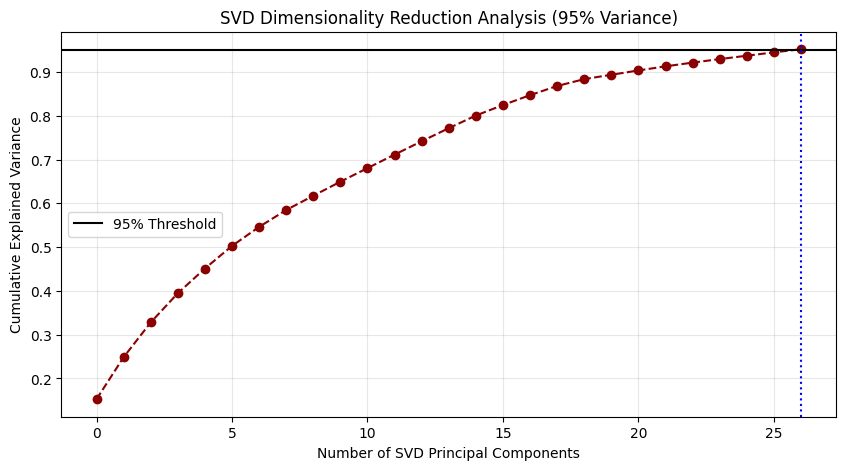

In [ ]:
# ---------------------------------------------------------
# PCA / SVD 
# ---------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mlflow.set_experiment("Regression_RandomForest_PCA_SVD")

# Identify numerical columns and apply StandardScaler (Mandatory for PCA/SVD)
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns 
scaler_pca = StandardScaler()
X_train_scaled_for_pca = X_train.copy()
X_test_scaled_for_pca = X_test.copy()
X_train_scaled_for_pca[num_cols] = scaler_pca.fit_transform(X_train[num_cols])
X_test_scaled_for_pca[num_cols] = scaler_pca.transform(X_test[num_cols])

# Execute PCA via SVD (95% Variance)
pca_svd_reg = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_svd = pca_svd_reg.fit_transform(X_train_scaled_for_pca)
X_test_svd = pca_svd_reg.transform(X_test_scaled_for_pca)

n_components_chosen = pca_svd_reg.n_components_
print(f"Original Features: {X_train.shape[1]}")
print(f"SVD Components needed for 95% variance: {n_components_chosen}\n")

# Define the Champion Model (RFR_GridSearch winner params)
champ_n_estimators = 150
champ_max_depth = 25
champ_min_samples_leaf = 10
champ_max_features = 1.0

# RUN A: Champion in Original Space (Unscaled, as RF natively prefers)
with mlflow.start_run(run_name="RFR_Champion_Original_Space"):
    model_orig = RandomForestRegressor(
        n_estimators=champ_n_estimators, 
        max_depth=champ_max_depth, 
        min_samples_leaf=champ_min_samples_leaf,
        max_features=champ_max_features,
        criterion="squared_error",
        random_state=42, 
        n_jobs=-1
    )
    
    start_time = time.time()
    model_orig.fit(X_train, y_train)
    time_orig = time.time() - start_time
    
    y_pred_orig = model_orig.predict(X_test)
    mae_orig = mean_absolute_error(y_test, y_pred_orig)
    rmse_orig = mean_squared_error(y_test, y_pred_orig) ** 0.5
    
    mlflow.log_param("space", "Original_Unscaled")
    mlflow.log_metric("fit_time", time_orig)
    mlflow.log_metric("mae_test", mae_orig)
    mlflow.log_metric("rmse_test", rmse_orig)

# RUN B: Champion in SVD Reduced Space
with mlflow.start_run(run_name="RFR_Champion_SVD_Space"):
    model_svd = RandomForestRegressor(
        n_estimators=champ_n_estimators, 
        max_depth=champ_max_depth, 
        min_samples_leaf=champ_min_samples_leaf,
        max_features=champ_max_features,
        criterion="squared_error",
        random_state=42, 
        n_jobs=-1
    )
    
    start_time = time.time()
    model_svd.fit(X_train_svd, y_train)
    time_svd = time.time() - start_time
    
    y_pred_svd = model_svd.predict(X_test_svd)
    mae_svd = mean_absolute_error(y_test, y_pred_svd)
    rmse_svd = mean_squared_error(y_test, y_pred_svd) ** 0.5
    
    mlflow.log_param("space", f"SVD_{n_components_chosen}_comps")
    mlflow.log_metric("fit_time", time_svd)
    mlflow.log_metric("mae_test", mae_svd)
    mlflow.log_metric("rmse_test", rmse_svd)

# Print Results
print("--- PCA/SVD IMPACT ON RANDOM FOREST REGRESSOR ---")
print(f"Original Space -> Fit Time: {time_orig:.4f}s | MAE: {mae_orig:.4f} | RMSE: {rmse_orig:.4f}")
print(f"SVD Space      -> Fit Time: {time_svd:.4f}s | MAE: {mae_svd:.4f} | RMSE: {rmse_svd:.4f}")

time_diff = ((time_svd - time_orig) / time_orig) * 100
print(f"\nExecution Time Change: {time_diff:+.1f}%")

# Scree Plot for the Report
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_svd_reg.explained_variance_ratio_), marker='o', linestyle='--', color='darkred')
plt.xlabel('Number of SVD Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD Dimensionality Reduction Analysis (95% Variance)')
plt.axhline(y=0.95, color='black', linestyle='-', label='95% Threshold')
plt.axvline(x=n_components_chosen-1, color='blue', linestyle=':')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**PCA/SVD Impact Analysis (Ridge Regressor)**

Reducing the original 53-feature space to 27 SVD components did not improve computational efficiency in this experiment. The fit time increased from 22.2002 s to 42.9487 s, which represents a 93.5% increase rather than a reduction. This is expected for a tree-based ensemble such as Random Forest: unlike a linear solver, it does not benefit from the orthogonal compression introduced by SVD in the same way, because the model already works by thresholding individual variables. In practice, the extra projection step adds overhead without providing a corresponding optimization advantage.

Predictive performance also deteriorated substantially after dimensionality reduction. MAE increased from 0.7249 to 1.5095 and RMSE increased from 0.9516 to 2.1434, showing that the SVD space lost important information for the regression task. Although SVD is mathematically useful for linear models because it creates orthogonal components and removes multicollinearity, that advantage is much less relevant for Random Forests, which are inherently robust to correlated features and do not rely on linear coefficient estimation. In this case, discarding 5% of the variance removed useful predictive signal rather than noise, so the original feature space remains clearly superior.